In [2]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


In [3]:
# Load the Titanic dataset
titanic_df = pd.read_csv("titanic.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Clean and preprocess the data
titanic_df = titanic_df.drop(columns=["Cabin", "Name", "Ticket", "PassengerId"])
titanic_df["Age"] = titanic_df["Age"].fillna(titanic_df["Age"].median())
titanic_df["Embarked"] = titanic_df["Embarked"].fillna(titanic_df["Embarked"].mode()[0])

titanic_df = pd.get_dummies(
    titanic_df,
    columns=["Sex", "Embarked"],
    drop_first=True,
    dtype=int,
)

features = [column for column in titanic_df.columns if column != "Survived"]
X = titanic_df[features]
y = titanic_df["Survived"]

print(f"Prepared dataset shape: {titanic_df.shape}")
print(f"Features: {features}")
print(f"Remaining missing values: {titanic_df.isna().sum().sum()}")

Prepared dataset shape: (891, 9)
Features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']
Remaining missing values: 0


In [5]:
# Split the data into training, development, and test sets
random_seed = 64

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=random_seed, stratify=y
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=random_seed, stratify=y_temp
)

print(f"Training rows: {len(X_train)}")
print(f"Development rows: {len(X_dev)}")
print(f"Test rows: {len(X_test)}")

Training rows: 534
Development rows: 178
Test rows: 179


In [6]:
# Train a baseline Random Forest model
baseline_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=random_seed,
    n_jobs=-1,
)
baseline_forest.fit(X_train, y_train)

baseline_dev_accuracy = accuracy_score(y_dev, baseline_forest.predict(X_dev))
print(f"Baseline development accuracy: {baseline_dev_accuracy:.3f}")

Baseline development accuracy: 0.848


Feature importances:
Fare          0.288407
Age           0.246004
Sex_male      0.237308
Pclass        0.090923
SibSp         0.054889
Parch         0.046494
Embarked_S    0.025325
Embarked_Q    0.010650
dtype: float64
Most important feature: Fare


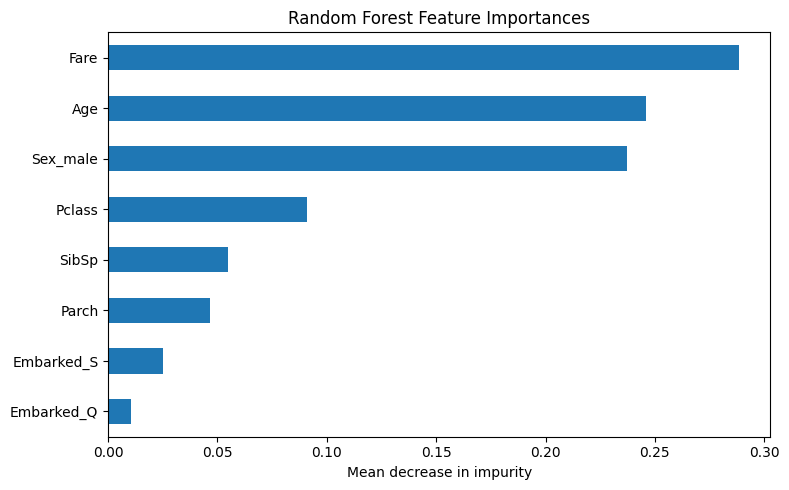

In [7]:
# Determine and plot feature importances
importance_results = pd.Series(
    baseline_forest.feature_importances_, index=features
).sort_values(ascending=False)

print("Feature importances:")
print(importance_results)
print(f"Most important feature: {importance_results.index[0]}")

plt.figure(figsize=(8, 5))
importance_results.sort_values().plot(kind="barh")
plt.xlabel("Mean decrease in impurity")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [8]:
# Tune n_estimators and max_depth
n_estimators_values = [50, 100, 200]
max_depth_values = [3, 5, 8, None]
tuning_results = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        tuned_forest = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=random_seed,
            n_jobs=-1,
        )
        tuned_forest.fit(X_train, y_train)

        tuning_results.append(
            {
                "n_estimators": n_estimators,
                "max_depth": max_depth if max_depth is not None else "None",
                "training_accuracy": accuracy_score(
                    y_train, tuned_forest.predict(X_train)
                ),
                "development_accuracy": accuracy_score(
                    y_dev, tuned_forest.predict(X_dev)
                ),
            }
        )

tuning_results = pd.DataFrame(tuning_results)
tuning_results = tuning_results.sort_values(
    "development_accuracy", ascending=False
).reset_index(drop=True)
tuning_results

,n_estimators,max_depth,training_accuracy,development_accuracy
0,50,8,0.938202,0.887640
1,100,8,0.932584,0.882022
2,200,8,0.934457,0.882022
3,200,5,0.874532,0.876404
4,100,5,0.876404,0.876404
5,50,5,0.878277,0.870787
6,50,None,0.985019,0.859551
7,200,None,0.986891,0.848315
8,100,None,0.986891,0.848315
9,50,3,0.823970,0.831461


In [9]:
# Train the best model on the combined training and development data
best_row = tuning_results.iloc[0]
best_n_estimators = int(best_row["n_estimators"])
best_max_depth = None if best_row["max_depth"] == "None" else int(best_row["max_depth"])

X_train_dev = pd.concat([X_train, X_dev])
y_train_dev = pd.concat([y_train, y_dev])

best_forest = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=random_seed,
    n_jobs=-1,
)
best_forest.fit(X_train_dev, y_train_dev)
final_test_accuracy = accuracy_score(y_test, best_forest.predict(X_test))

best_importances = pd.Series(
    best_forest.feature_importances_, index=features
).sort_values(ascending=False)

print(f"Best n_estimators: {best_n_estimators}")
print(f"Best max_depth: {best_max_depth}")
print(f"Best development accuracy: {best_row['development_accuracy']:.3f}")
print(f"Final test accuracy: {final_test_accuracy:.3f}")
print(f"Most important feature in the final model: {best_importances.index[0]}")

Best n_estimators: 50
Best max_depth: 8
Best development accuracy: 0.888
Final test accuracy: 0.765
Most important feature in the final model: Sex_male


**Summary of findings**

The Titanic data was cleaned by removing identifier and text columns, imputing missing `Age` and `Embarked` values, and one-hot encoding the categorical variables with `drop_first=True`. The prepared data contained 891 passengers and eight numeric features.

The baseline Random Forest achieved a development accuracy of 0.848. In that baseline model, `Fare` had the highest feature importance, followed by `Age` and `Sex_male`. After tuning, the final model's importance ranking identified `Sex_male` as the strongest feature, showing that importance can vary with the model configuration and training data.

The tuning process tested all 12 combinations of `n_estimators` values 50, 100, and 200 with `max_depth` values 3, 5, 8, and None. The best development accuracy was 0.888 using `n_estimators = 50` and `max_depth = 8`. After retraining this configuration on the combined training and development data, the final test accuracy was 0.765.